# Notebook 09: Wheat Crop Analytics & Advanced Visualizations
This notebook provides 20 distinct, publication-quality visualizations analyzing wheat crop monitoring datasets. The visual analyses cover:
1. **Sown Area Analytics**: Model estimates vs. Ministry ground truth.
2. **Yield Forecasting Performance**: Predicted vs. actual yields, residual diagnostics, and state-level aggregations.
3. **Vegetation Health Index (VHI) Dynamics**: Fortnightly progressions, seasonality, anomalies, and spatial heatmaps.
4. **Historical Crop Analytics**: historic yields, volatility, and district-level distribution profiles.

We utilize `pandas`, `matplotlib`, and `seaborn` with custom styling for a premium presentation.

## Environment Setup & Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for publication-quality plots
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100
})

# Define harmonious color schemes
accent_color = "#1a3a5c"
secondary_color = "#2e6da4"

print("Setup complete. Plotting environment initialized.")

Setup complete. Plotting environment initialized.


## Dataset Loading & Preprocessing

In [2]:
# Load available datasets
district_yield_hist = pd.read_csv('../data/sample/district_yield_history.csv')
ministry_gt = pd.read_csv('../data/sample/ministry_ground_truth.csv')
sown_area_est = pd.read_csv('../outputs/sown_area_estimates.csv')
vhi_fortnightly = pd.read_csv('../outputs/vhi_fortnightly.csv')
yield_fc = pd.read_csv('../outputs/yield_forecast.csv')
state_yield_fc = pd.read_csv('../outputs/state_yield_forecast.csv')
eval_matrix = pd.read_csv('../outputs/evaluation_matrix.csv')

# Preprocess / Join datasets for comparison
sown_comparison = pd.merge(
    sown_area_est.rename(columns={'area_lakh_ha': 'model_sown_area_lakh_ha'}),
    ministry_gt,
    on='state',
    how='inner'
)

yield_comparison = pd.merge(
    state_yield_fc.rename(columns={'state_yield_t_ha': 'model_yield_t_ha'}),
    ministry_gt,
    on='state',
    how='inner'
)

print("All datasets loaded and preprocessed successfully.")

All datasets loaded and preprocessed successfully.


### 1. Sown Area Comparison (Model Estimates vs. Ministry Ground Truth)
Comparing the model's estimated sown area (lakh ha) with the official Ministry ground truth per state.

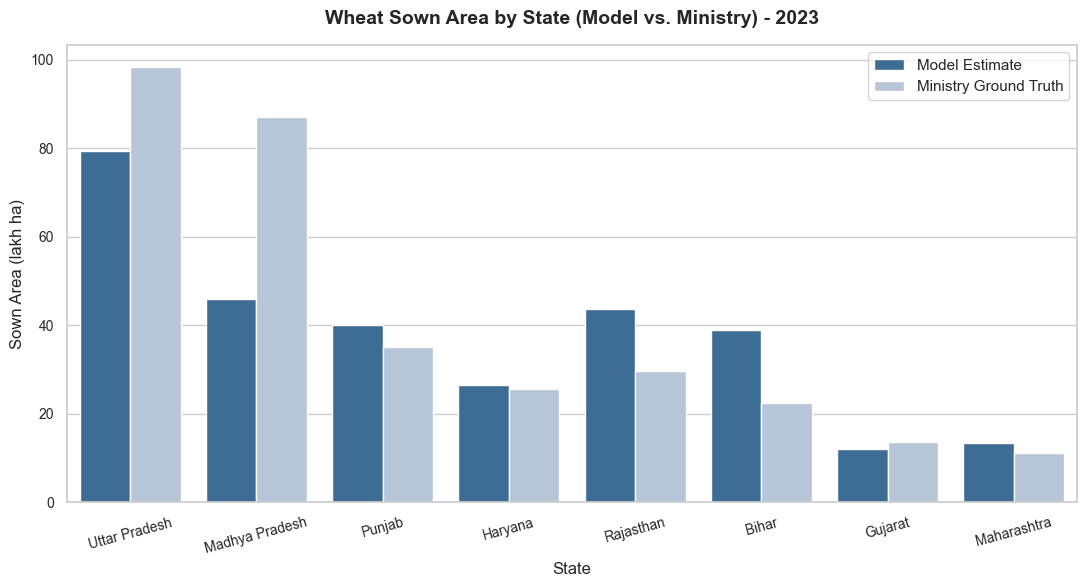

In [3]:
plt.figure(figsize=(11, 6))
df_melted = sown_comparison.melt(
    id_vars='state', 
    value_vars=['model_sown_area_lakh_ha', 'ministry_sown_area_lakh_ha'],
    var_name='Source', 
    value_name='Sown Area (lakh ha)'
)
df_melted['Source'] = df_melted['Source'].replace({
    'model_sown_area_lakh_ha': 'Model Estimate',
    'ministry_sown_area_lakh_ha': 'Ministry Ground Truth'
})

sns.barplot(data=df_melted, x='state', y='Sown Area (lakh ha)', hue='Source', palette=['#2e6da4', '#b0c4de'])
plt.title('Wheat Sown Area by State (Model vs. Ministry) - 2023', fontweight='bold', pad=15)
plt.xlabel('State')
plt.ylabel('Sown Area (lakh ha)')
plt.xticks(rotation=15)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 2. Yield Forecast vs. Actual Yield at District Level
A scatter plot with a 45-degree reference line comparing actual vs. predicted yields (t/ha) across all districts.

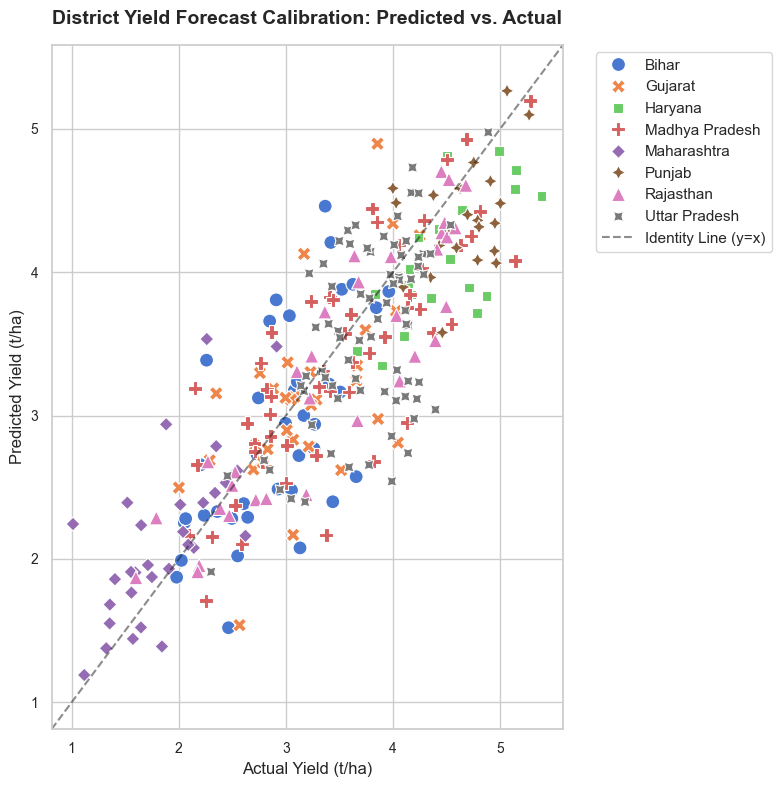

In [4]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=yield_fc, x='yield_actual', y='yield_pred', hue='state', style='state', s=100)
# Add 45-degree identity line
max_val = max(yield_fc['yield_actual'].max(), yield_fc['yield_pred'].max())
min_val = min(yield_fc['yield_actual'].min(), yield_fc['yield_pred'].min())
plt.plot([min_val - 0.2, max_val + 0.2], [min_val - 0.2, max_val + 0.2], 'k--', alpha=0.5, label='Identity Line (y=x)')

plt.title('District Yield Forecast Calibration: Predicted vs. Actual', fontweight='bold', pad=15)
plt.xlabel('Actual Yield (t/ha)')
plt.ylabel('Predicted Yield (t/ha)')
plt.xlim(min_val - 0.2, max_val + 0.2)
plt.ylim(min_val - 0.2, max_val + 0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### 3. Distribution of Yield Prediction Residuals
Kernel Density Estimate (KDE) and histogram of prediction residuals (Predicted - Actual) to analyze bias and normality.

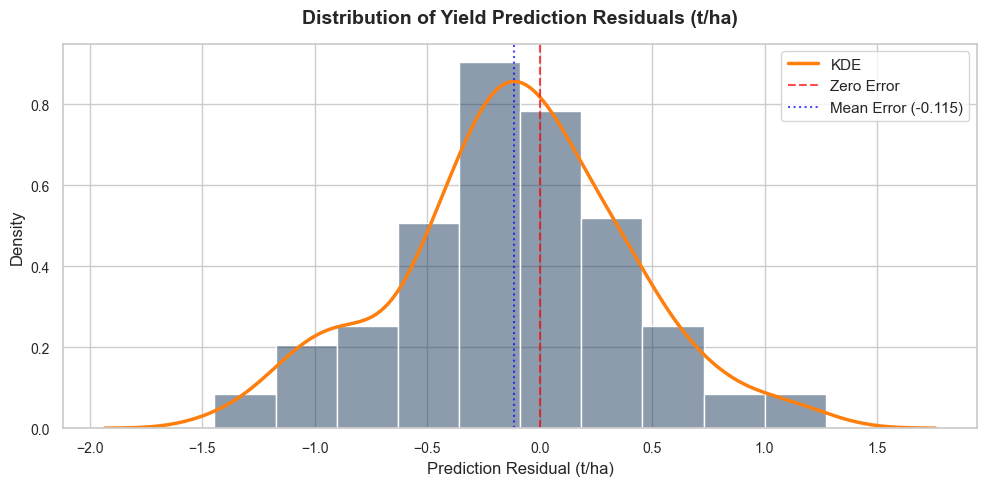

In [5]:
plt.figure(figsize=(10, 5))
residuals = yield_fc['yield_pred'] - yield_fc['yield_actual']
sns.histplot(residuals, kde=True, color='#1a3a5c', bins=10, stat="density")
sns.kdeplot(residuals, color='#ff7f0e', linewidth=2.5, label='KDE')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Error')
plt.axvline(x=residuals.mean(), color='blue', linestyle=':', alpha=0.7, label=f'Mean Error ({residuals.mean():.3f})')

plt.title('Distribution of Yield Prediction Residuals (t/ha)', fontweight='bold', pad=15)
plt.xlabel('Prediction Residual (t/ha)')
plt.ylabel('Density')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 4. State-Level Yield Forecast vs. Ministry Ground Truth
Comparing the aggregated model yield forecasts with the official Ministry yield targets (t/ha) per state.

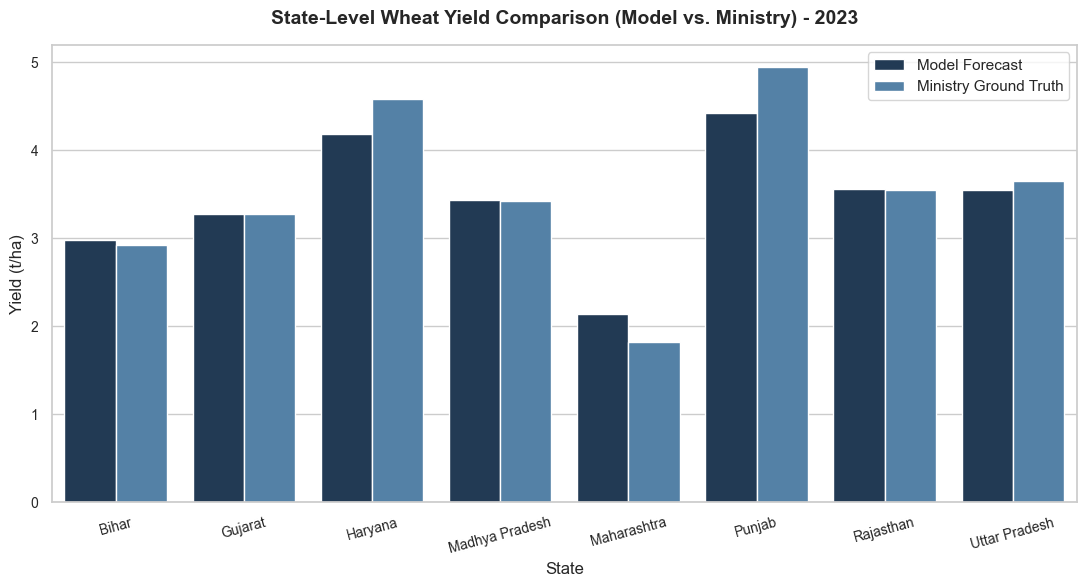

In [6]:
plt.figure(figsize=(11, 6))
yield_melted = yield_comparison.melt(
    id_vars='state', 
    value_vars=['model_yield_t_ha', 'ministry_yield_t_ha'],
    var_name='Source', 
    value_name='Yield (t/ha)'
)
yield_melted['Source'] = yield_melted['Source'].replace({
    'model_yield_t_ha': 'Model Forecast',
    'ministry_yield_t_ha': 'Ministry Ground Truth'
})

sns.barplot(data=yield_melted, x='state', y='Yield (t/ha)', hue='Source', palette=['#1a3a5c', '#4682b4'])
plt.title('State-Level Wheat Yield Comparison (Model vs. Ministry) - 2023', fontweight='bold', pad=15)
plt.xlabel('State')
plt.ylabel('Yield (t/ha)')
plt.xticks(rotation=15)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 5. Regression Plot: Model Sown Area vs. Ministry Sown Area
Evaluates the linear relationship and correlation strength between the model estimates and ground truth.

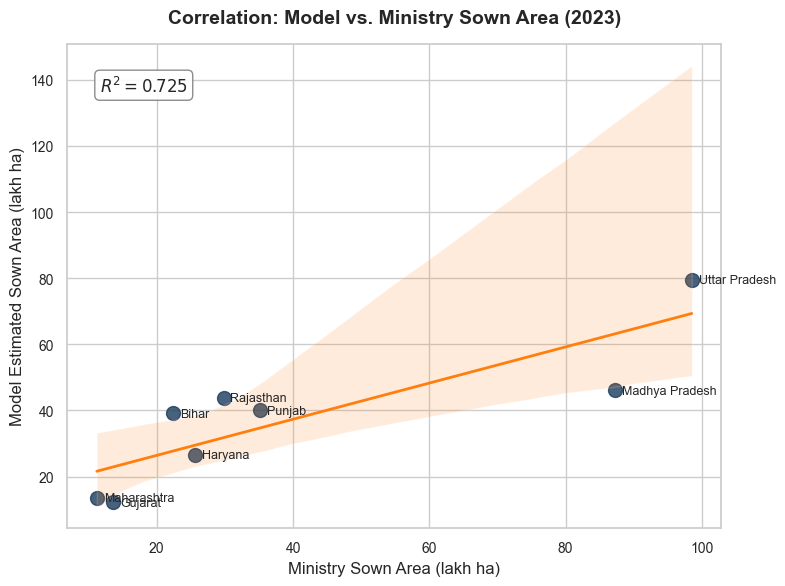

In [7]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sown_comparison, 
    x='ministry_sown_area_lakh_ha', 
    y='model_sown_area_lakh_ha',
    scatter_kws={'s': 100, 'color': '#1a3a5c'}, 
    line_kws={'color': '#ff7f0e', 'lw': 2}
)
# Add labels for states
for idx, row in sown_comparison.iterrows():
    plt.text(row['ministry_sown_area_lakh_ha']+1, row['model_sown_area_lakh_ha']-1, row['state'], fontsize=9)

r2 = sown_comparison['model_sown_area_lakh_ha'].corr(sown_comparison['ministry_sown_area_lakh_ha'])**2
plt.title('Correlation: Model vs. Ministry Sown Area (2023)', fontweight='bold', pad=15)
plt.xlabel('Ministry Sown Area (lakh ha)')
plt.ylabel('Model Estimated Sown Area (lakh ha)')
plt.annotate(f'$R^2 = {r2:.3f}$', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12, fontweight='bold', bbox=dict(boxstyle="round", fc="w", ec="0.5", alpha=0.9))
plt.tight_layout()
plt.show()

### 6. Fortnightly VHI Trend Progression
Line chart tracking the fortnightly Vegetation Health Index (VHI) trends from November to April across states.

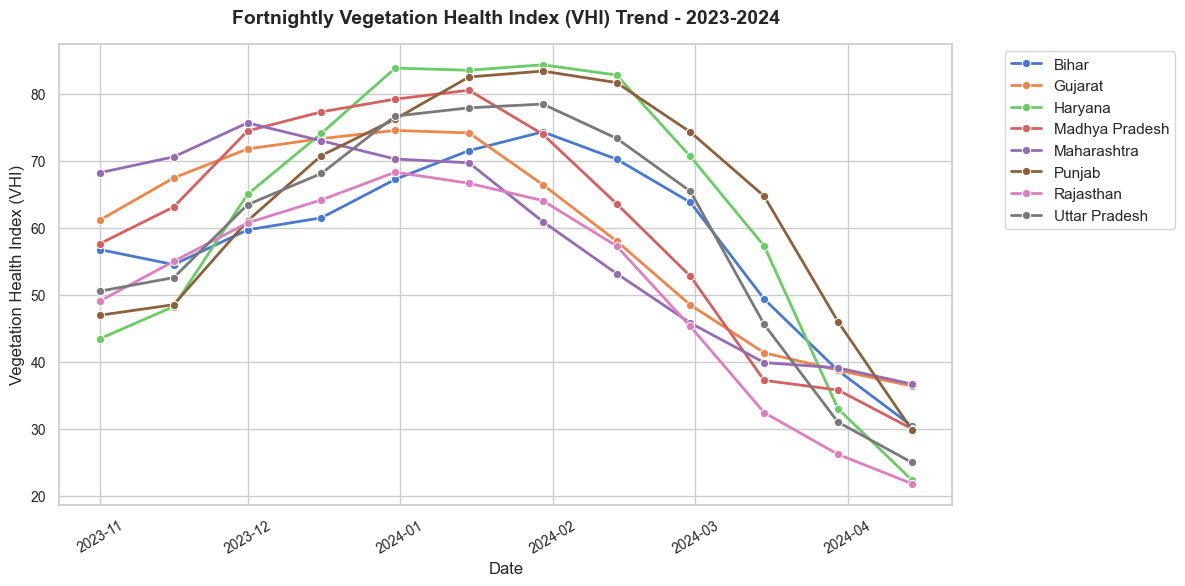

In [8]:
plt.figure(figsize=(12, 6))
# Sort values by date to ensure proper timeline connection
vhi_sorted = vhi_fortnightly.copy()
vhi_sorted['date'] = pd.to_datetime(vhi_sorted['date'])
vhi_sorted = vhi_sorted.sort_values(['state', 'date'])

sns.lineplot(data=vhi_sorted, x='date', y='VHI', hue='state', marker='o', linewidth=2, markersize=6)
plt.title('Fortnightly Vegetation Health Index (VHI) Trend - 2023-2024', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Vegetation Health Index (VHI)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 7. VHI Distribution Ranges by State
Box plot summarizing the spread, median, and dynamic range of VHI values for each state across the entire agricultural season.

C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\172278633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vhi_fortnightly, x='state', y='VHI', palette='crest')


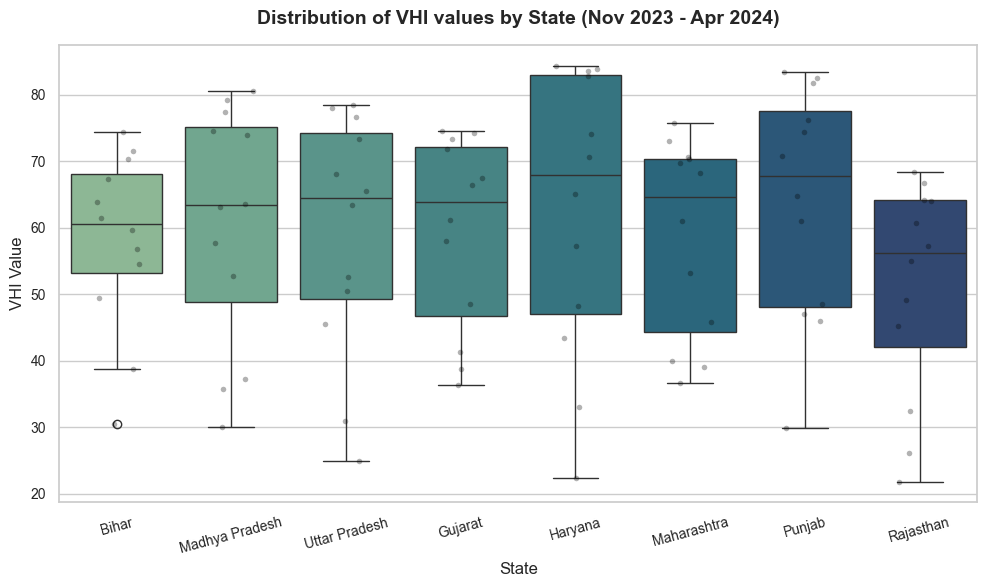

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=vhi_fortnightly, x='state', y='VHI', palette='crest')
sns.stripplot(data=vhi_fortnightly, x='state', y='VHI', color='black', alpha=0.3, size=4, jitter=0.2)
plt.title('Distribution of VHI values by State (Nov 2023 - Apr 2024)', fontweight='bold', pad=15)
plt.xlabel('State')
plt.ylabel('VHI Value')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 8. Historical District Yield Trends (2020-2023)
Plots historical yield trends across all districts to analyze long-term patterns and inter-annual variability.

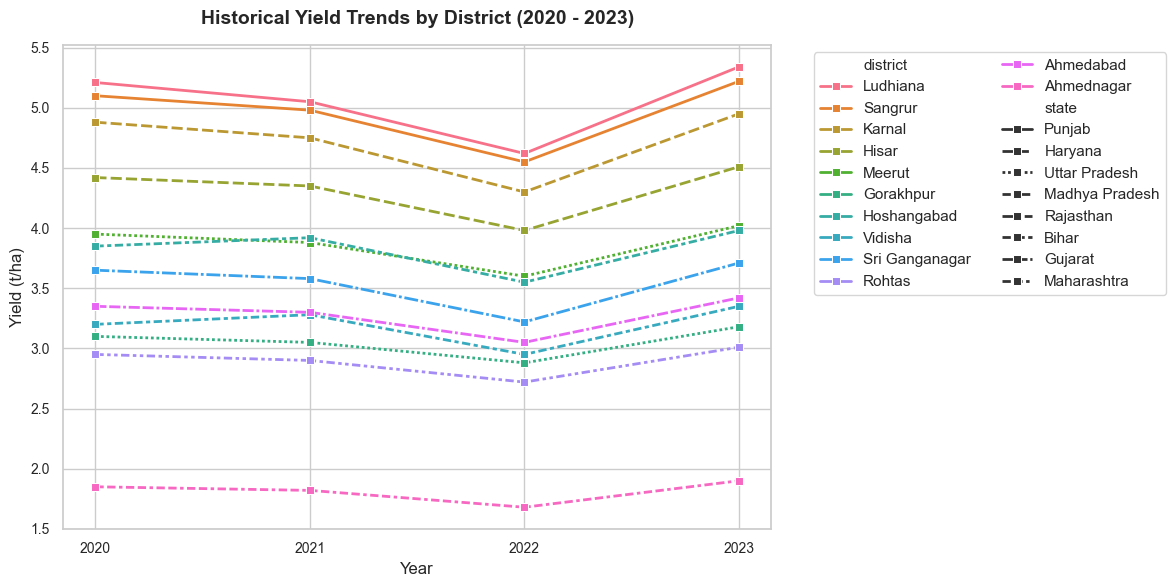

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=district_yield_hist, x='year', y='yield_t_ha', hue='district', style='state', marker='s', linewidth=2)
plt.title('Historical Yield Trends by District (2020 - 2023)', fontweight='bold', pad=15)
plt.xlabel('Year')
plt.ylabel('Yield (t/ha)')
plt.xticks([2020, 2021, 2022, 2023])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, frameon=True)
plt.tight_layout()
plt.show()

### 9. Violin Plot: District Sown Area Distribution by State
Visualizes the density and spread of district-level sown areas (kha) within different states for the year 2023.

C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\4045243762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_2023, x='state', y='sown_area_kha', inner='quartile', palette='pastel')


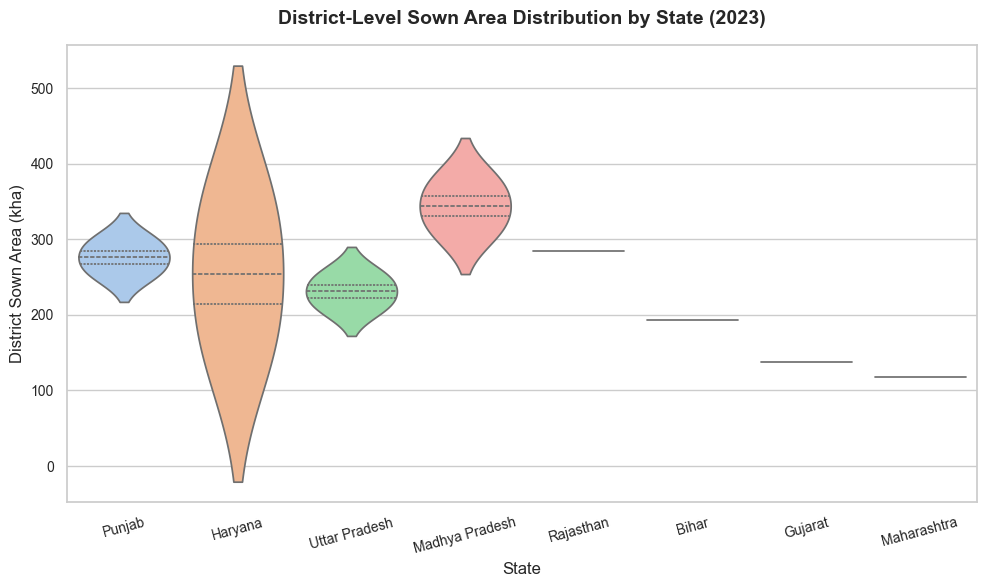

In [11]:
plt.figure(figsize=(10, 6))
df_2023 = district_yield_hist[district_yield_hist['year'] == 2023]
sns.violinplot(data=df_2023, x='state', y='sown_area_kha', inner='quartile', palette='pastel')
plt.title('District-Level Sown Area Distribution by State (2023)', fontweight='bold', pad=15)
plt.xlabel('State')
plt.ylabel('District Sown Area (kha)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 10. Spatio-Temporal VHI Heatmap (State vs. Date)
Heatmap illustrating Vegetation Health Index values with states as rows and fortnightly dates as columns, emphasizing temporal shifts.

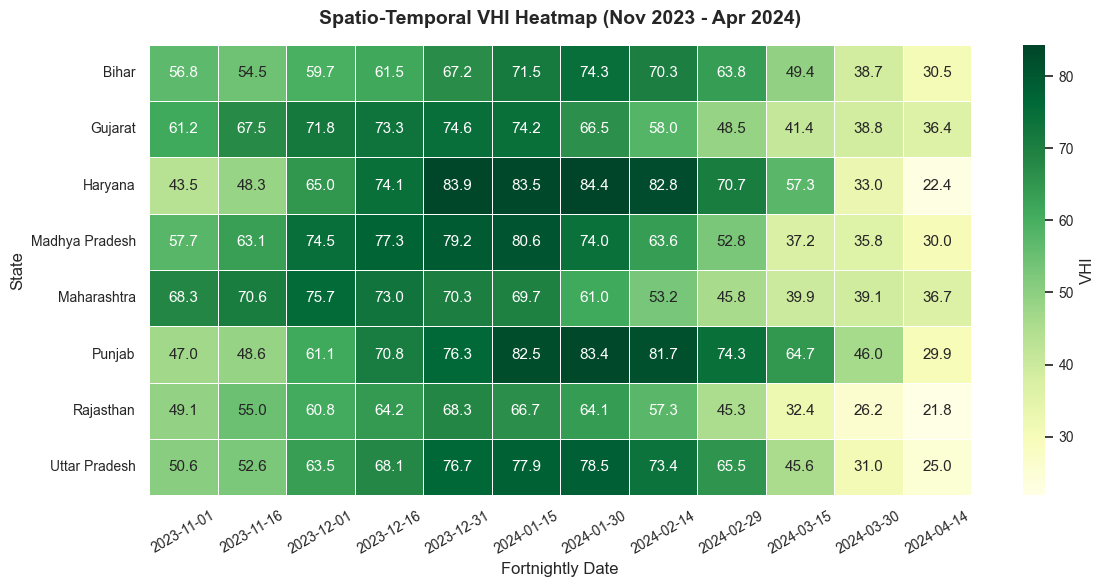

In [12]:
plt.figure(figsize=(12, 6))
vhi_pivot = vhi_fortnightly.pivot(index='state', columns='date', values='VHI')
sns.heatmap(vhi_pivot, cmap='YlGn', annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': 'VHI'})
plt.title('Spatio-Temporal VHI Heatmap (Nov 2023 - Apr 2024)', fontweight='bold', pad=15)
plt.xlabel('Fortnightly Date')
plt.ylabel('State')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 11. Historic Variables Correlation Heatmap
Pearson correlation heatmap analyzing interactions between variables in the historical district dataset.

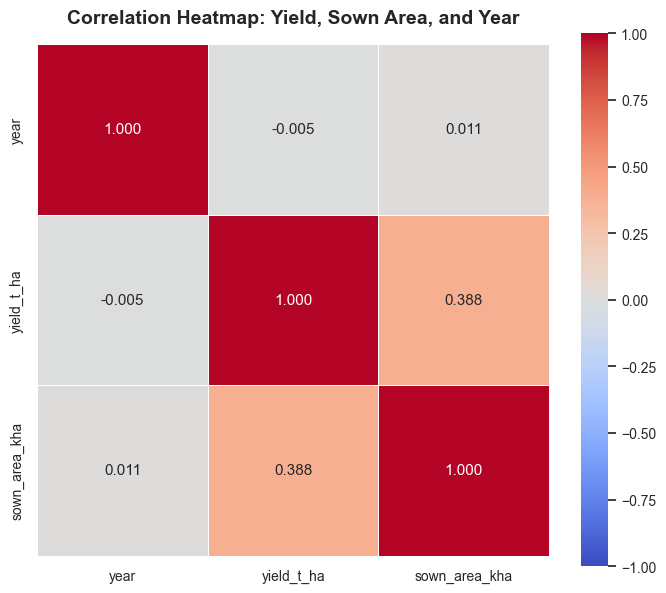

In [13]:
plt.figure(figsize=(7, 6))
corr_matrix = district_yield_hist[['year', 'yield_t_ha', 'sown_area_kha']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", square=True, linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Yield, Sown Area, and Year', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 12. Model Performance Evaluation Metrics
A multi-panel bar plot showing the evaluation metrics (R², RMSE, and absolute Bias) for Sown Area and Yield predictions.

C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\3736528811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_matrix, x='variable', y='r2', ax=axes[0], palette='Blues_r')
C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\3736528811.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_matrix, x='variable', y='rmse', ax=axes[1], palette='Oranges_r')
C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\3736528811.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_matrix, x='variable', y='bias', ax=axe

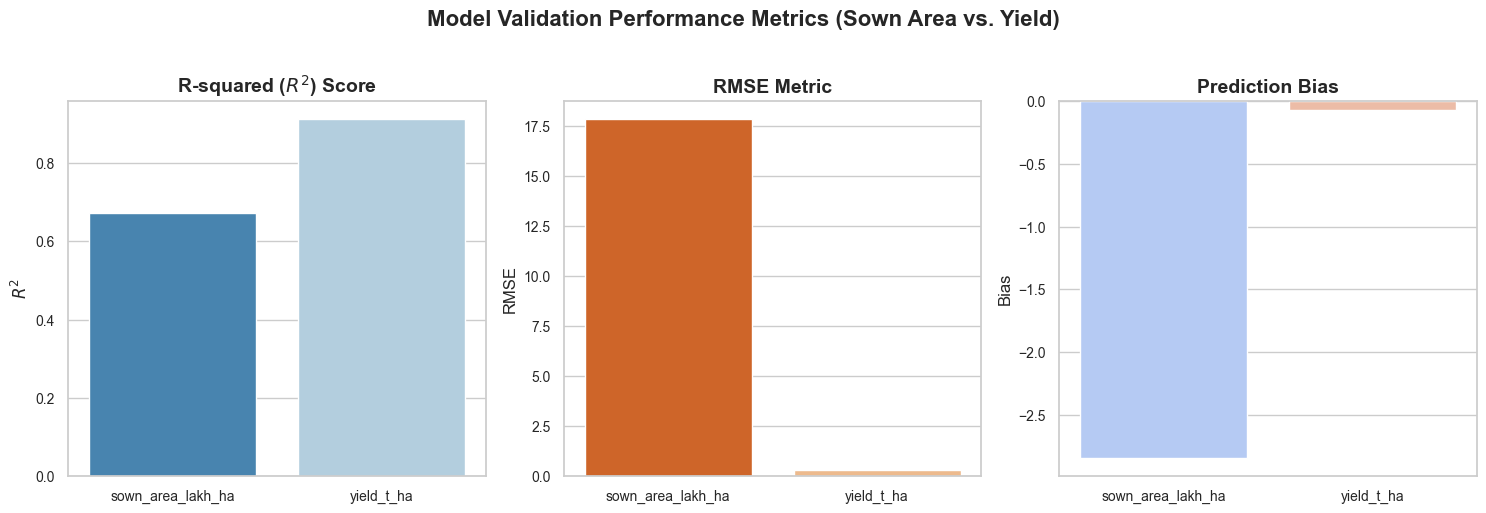

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot R2
sns.barplot(data=eval_matrix, x='variable', y='r2', ax=axes[0], palette='Blues_r')
axes[0].set_title('R-squared ($R^2$) Score', fontweight='bold')
axes[0].set_ylabel('$R^2$')
axes[0].set_xlabel('')

# Plot RMSE
sns.barplot(data=eval_matrix, x='variable', y='rmse', ax=axes[1], palette='Oranges_r')
axes[1].set_title('RMSE Metric', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('')

# Plot Bias
sns.barplot(data=eval_matrix, x='variable', y='bias', ax=axes[2], palette='coolwarm')
axes[2].set_title('Prediction Bias', fontweight='bold')
axes[2].set_ylabel('Bias')
axes[2].set_xlabel('')

plt.suptitle('Model Validation Performance Metrics (Sown Area vs. Yield)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 13. Joint Plot: District Yield vs. Sown Area (2023)
A joint scatter plot showing marginal distribution histograms and correlation between sown area and yield.

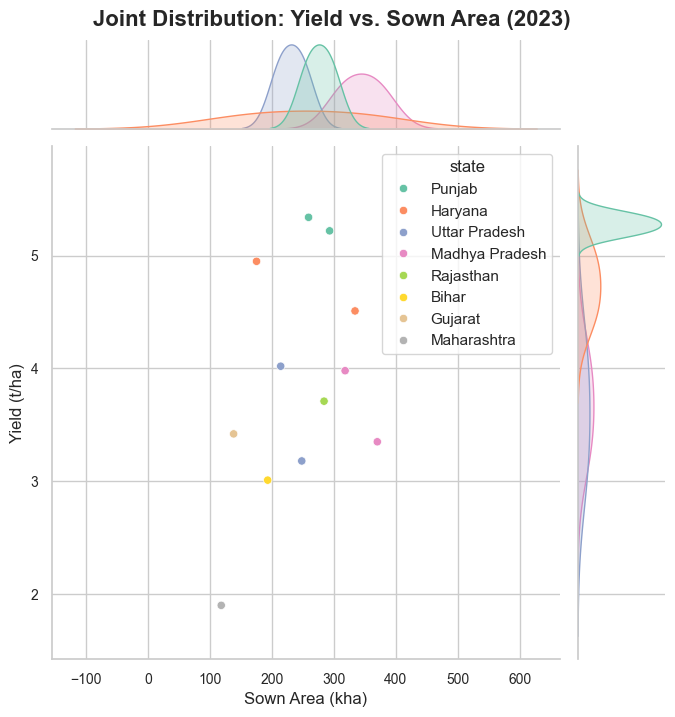

In [15]:
g = sns.jointplot(
    data=district_yield_hist[district_yield_hist['year'] == 2023], 
    x='sown_area_kha', 
    y='yield_t_ha',
    hue='state', 
    kind='scatter', 
    palette='Set2', 
    height=7, 
    space=0.2
)
g.fig.suptitle('Joint Distribution: Yield vs. Sown Area (2023)', fontweight='bold', y=1.02)
g.set_axis_labels('Sown Area (kha)', 'Yield (t/ha)')
plt.show()

### 14. Percentage Sown Area Contribution by State
A clean donut chart showing each state's percentage share of the total model-estimated sown area in 2023.

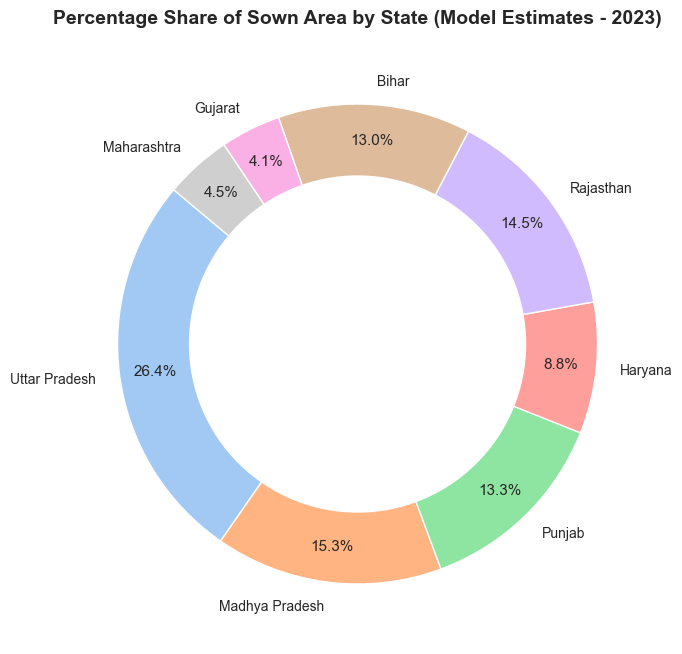

In [16]:
plt.figure(figsize=(7, 7))
colors_list = sns.color_palette('pastel')[0:len(sown_area_est)]
plt.pie(
    sown_area_est['area_lakh_ha'], 
    labels=sown_area_est['state'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_list,
    pctdistance=0.85
)

# Draw circle to convert Pie to Donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Percentage Share of Sown Area by State (Model Estimates - 2023)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 15. Seasonality Profile: Mean VHI across Fortnights
Aggregates VHI across all states to show the general agricultural seasonal timeline and crop vegetative progression.

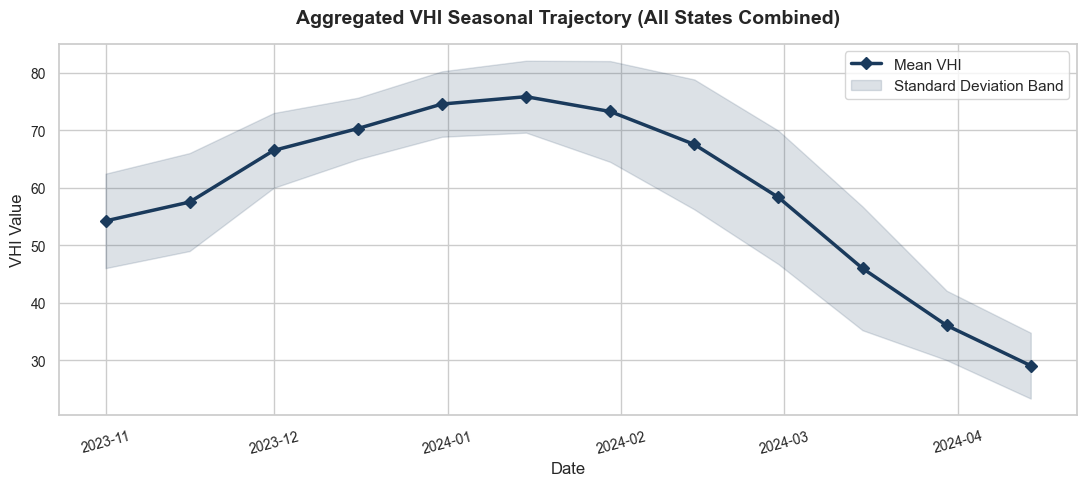

In [17]:
plt.figure(figsize=(11, 5))
vhi_mean = vhi_fortnightly.groupby('date')['VHI'].agg(['mean', 'std']).reset_index()
vhi_mean['date'] = pd.to_datetime(vhi_mean['date'])

plt.plot(vhi_mean['date'], vhi_mean['mean'], marker='D', color='#1a3a5c', linewidth=2.5, label='Mean VHI')
plt.fill_between(
    vhi_mean['date'], 
    vhi_mean['mean'] - vhi_mean['std'], 
    vhi_mean['mean'] + vhi_mean['std'], 
    color='#1a3a5c', 
    alpha=0.15, 
    label='Standard Deviation Band'
)

plt.title('Aggregated VHI Seasonal Trajectory (All States Combined)', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('VHI Value')
plt.xticks(rotation=15)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 16. District Yield Prediction Spread within States
Horizontal box plots displaying the spread and variability of individual district yield forecasts within each state.

C:\Users\SHIVANSHU\AppData\Local\Temp\ipykernel_25016\1679386992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


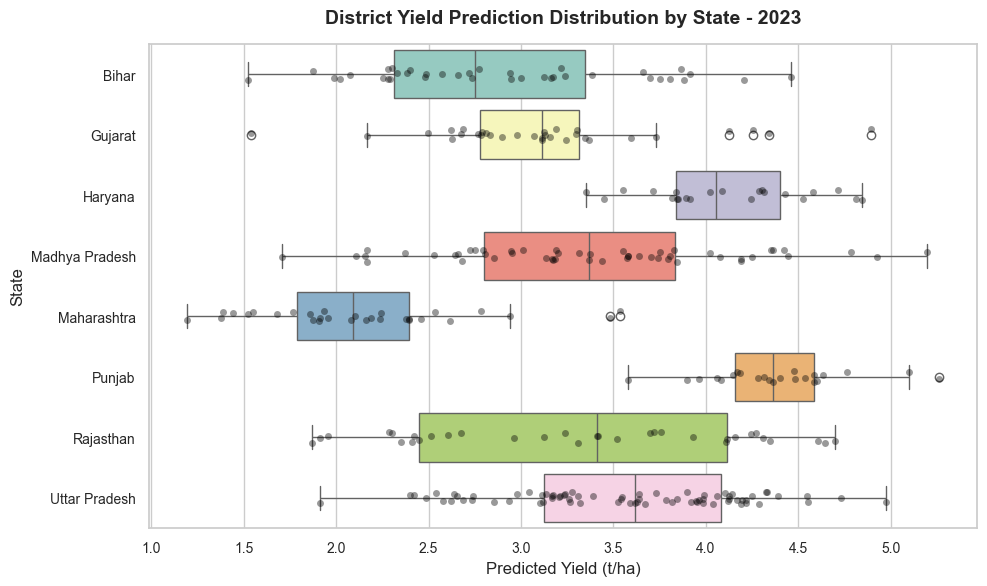

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=yield_fc, 
    y='state', 
    x='yield_pred', 
    palette='Set3', 
    orient='h'
)
sns.stripplot(
    data=yield_fc, 
    y='state', 
    x='yield_pred', 
    color='black', 
    alpha=0.4, 
    size=5, 
    jitter=0.1, 
    orient='h'
)
plt.title('District Yield Prediction Distribution by State - 2023', fontweight='bold', pad=15)
plt.ylabel('State')
plt.xlabel('Predicted Yield (t/ha)')
plt.tight_layout()
plt.show()

### 17. Historical Yield Volatility by District (Coefficient of Variation)
Measures the inter-annual yield volatility of each district using the historical Coefficient of Variation (CV).

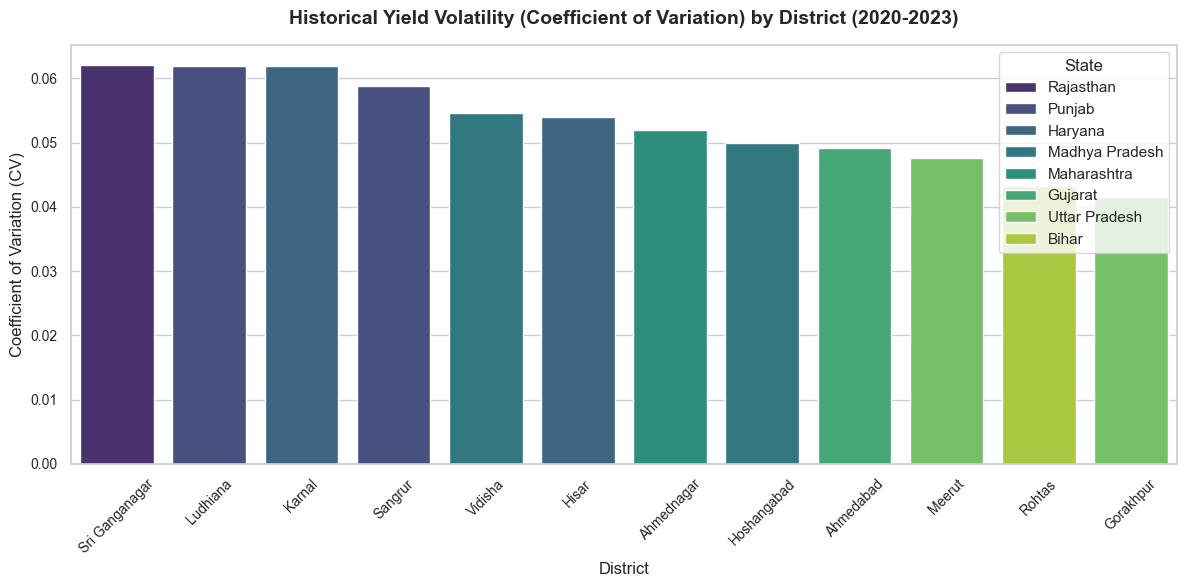

In [19]:
# Calculate CV: Std / Mean
volatility = district_yield_hist.groupby(['state', 'district'])['yield_t_ha'].agg(
    lambda x: x.std() / x.mean()
).reset_index().rename(columns={'yield_t_ha': 'CV'})

plt.figure(figsize=(12, 6))
sns.barplot(
    data=volatility.sort_values('CV', ascending=False), 
    x='district', 
    y='CV', 
    hue='state', 
    dodge=False, 
    palette='viridis'
)
plt.title('Historical Yield Volatility (Coefficient of Variation) by District (2020-2023)', fontweight='bold', pad=15)
plt.xlabel('District')
plt.ylabel('Coefficient of Variation (CV)')
plt.xticks(rotation=45)
plt.legend(title='State', frameon=True)
plt.tight_layout()
plt.show()

### 18. VHI Dynamic Range Plot by State
A range/dumbbell plot illustrating the minimum and maximum recorded VHI values per state, indicating peak-to-trough vegetation index shifts.

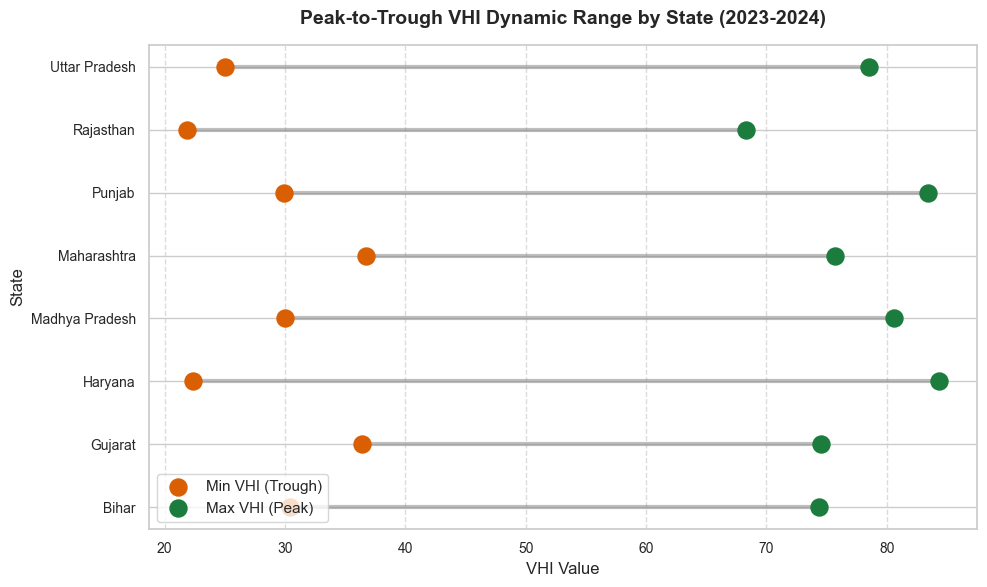

In [20]:
vhi_minmax = vhi_fortnightly.groupby('state')['VHI'].agg(['min', 'max']).reset_index()

plt.figure(figsize=(10, 6))
plt.hlines(
    y=vhi_minmax['state'], 
    xmin=vhi_minmax['min'], 
    xmax=vhi_minmax['max'], 
    color='grey', 
    alpha=0.5, 
    linewidth=3
)
plt.scatter(
    vhi_minmax['min'], 
    vhi_minmax['state'], 
    color='#d95f02', 
    alpha=1.0, 
    s=150, 
    label='Min VHI (Trough)', 
    zorder=3
)
plt.scatter(
    vhi_minmax['max'], 
    vhi_minmax['state'], 
    color='#1b7c3d', 
    alpha=1.0, 
    s=150, 
    label='Max VHI (Peak)', 
    zorder=3
)

plt.title('Peak-to-Trough VHI Dynamic Range by State (2023-2024)', fontweight='bold', pad=15)
plt.xlabel('VHI Value')
plt.ylabel('State')
plt.legend(frameon=True, loc='lower left')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 19. Side-by-Side Sown Area Percentage Share Comparison
Side-by-side donut charts comparing the percentage share of sown area by state under Model predictions vs. Ministry data.

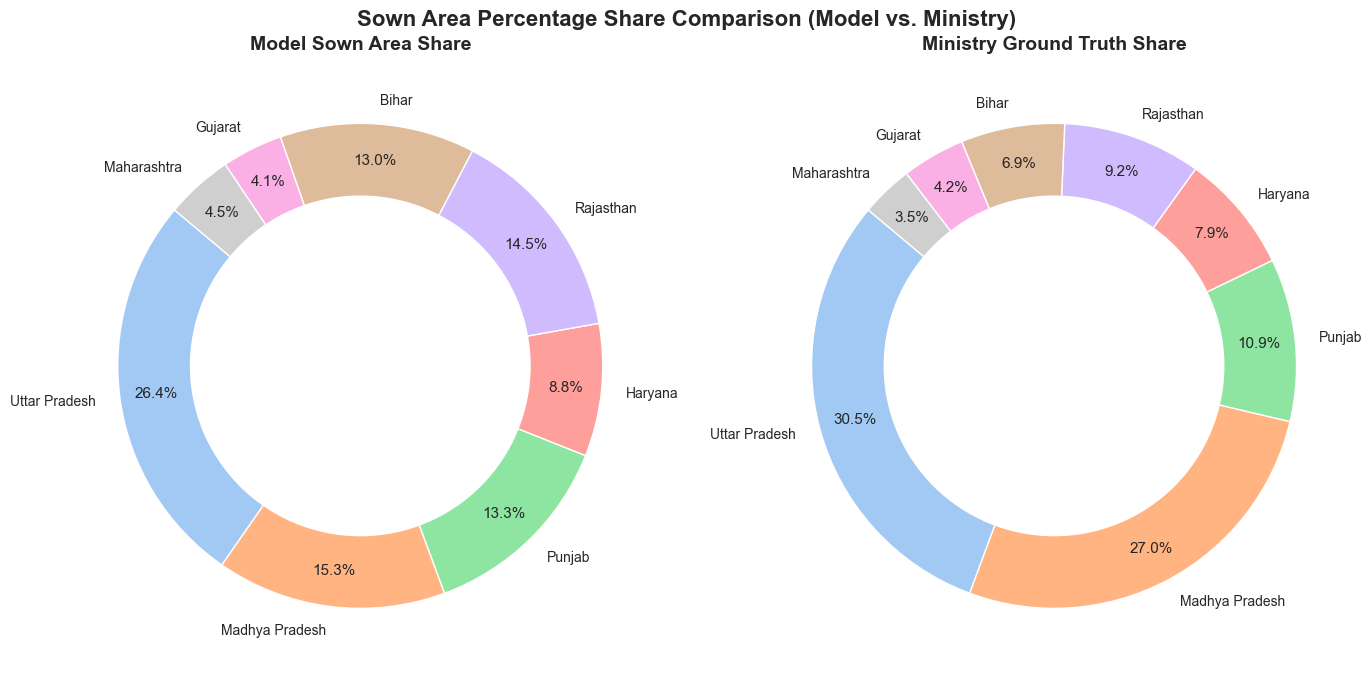

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors_list = sns.color_palette('pastel')[0:len(sown_comparison)]

# Model Pie
axes[0].pie(
    sown_comparison['model_sown_area_lakh_ha'], 
    labels=sown_comparison['state'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_list,
    pctdistance=0.85
)
axes[0].add_artist(plt.Circle((0,0),0.70,fc='white'))
axes[0].set_title('Model Sown Area Share', fontweight='bold', pad=10)

# Ministry Pie
axes[1].pie(
    sown_comparison['ministry_sown_area_lakh_ha'], 
    labels=sown_comparison['state'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_list,
    pctdistance=0.85
)
axes[1].add_artist(plt.Circle((0,0),0.70,fc='white'))
axes[1].set_title('Ministry Ground Truth Share', fontweight='bold', pad=10)

plt.suptitle('Sown Area Percentage Share Comparison (Model vs. Ministry)', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

### 20. Pairplot: Multi-Variable Matrix Analysis
Matrix of pairwise scatter plots and diagonal KDEs analyzing multi-variable relationships across states in the historical yield dataset.

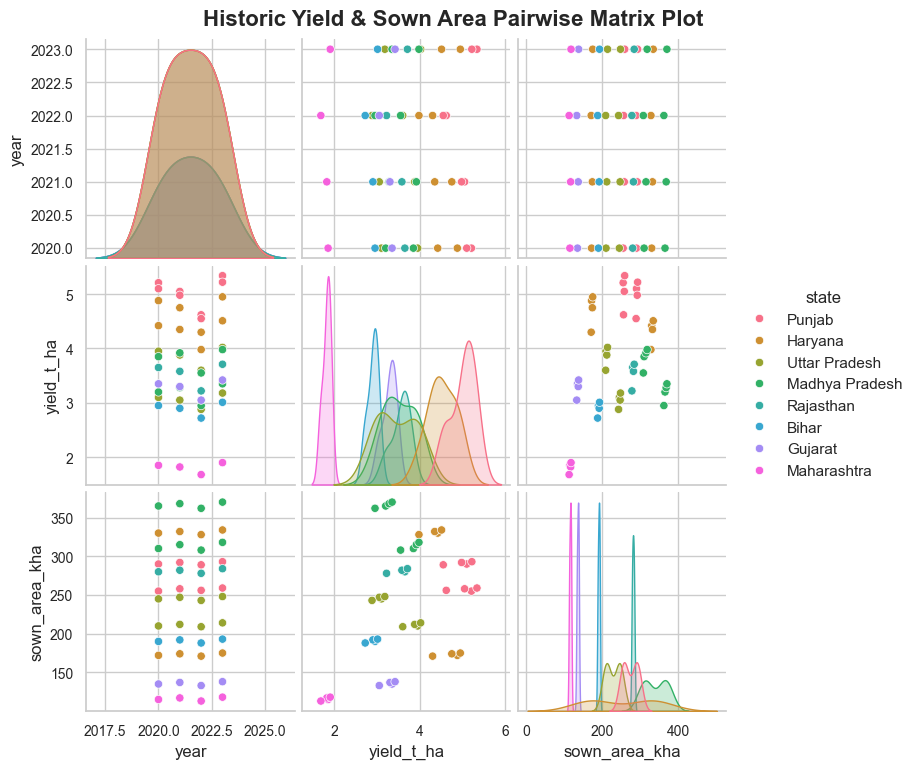

In [22]:
g = sns.pairplot(
    data=district_yield_hist, 
    hue='state', 
    vars=['year', 'yield_t_ha', 'sown_area_kha'], 
    palette='husl', 
    diag_kind='kde',
    height=2.5
)
g.fig.suptitle('Historic Yield & Sown Area Pairwise Matrix Plot', fontweight='bold', y=1.02)
plt.show()